In [1]:
import os
import shutil
import random
import nibabel as nib
import numpy as np
import cv2
from tqdm import tqdm
from collections import defaultdict
from sklearn.model_selection import train_test_split

# --- Configuration des chemins ---
BASE_DIR = "data/MSD_pancreas"
IMG_DIR = os.path.join(BASE_DIR, "3D_scans")
LBL_DIR = os.path.join(BASE_DIR, "labels")
OUTPUT_ROOT = "data/MSD_pancreas"

# Paramètres de fenêtrage (HU) pour le pancréas
WINDOW_CENTER = 40 
WINDOW_WIDTH = 400 

def apply_windowing(img_array):
    """Convertit les unités Hounsfield en 0-255 pour le contraste mou."""
    img_min = WINDOW_CENTER - (WINDOW_WIDTH / 2)
    img_max = WINDOW_CENTER + (WINDOW_WIDTH / 2)
    img_array = np.clip(img_array, img_min, img_max)
    img_array = (img_array - img_min) / (img_max - img_min) * 255.0
    return img_array.astype(np.uint8)

def extract_slices(patient_list, target_total, folder_name, tumor_ratio=0.60):
    """Extrait un nombre exact d'images avec un ratio exact de tumeurs."""
    
    # 1. Nettoyage pour éviter l'accumulation (Le fix du 1337)
    out_img_dir = os.path.join(OUTPUT_ROOT, folder_name, "images")
    out_mask_dir = os.path.join(OUTPUT_ROOT, folder_name, "masks")
    if os.path.exists(out_img_dir): shutil.rmtree(out_img_dir)
    if os.path.exists(out_mask_dir): shutil.rmtree(out_mask_dir)
    os.makedirs(out_img_dir)
    os.makedirs(out_mask_dir)

    tumor_candidates = []
    healthy_candidates = []

    # 2. Phase de catalogage (sans extraire l'image entière pour aller vite)
    for p_name in tqdm(patient_list, desc=f"Cataloging {folder_name}"):
        lbl = nib.load(os.path.join(LBL_DIR, p_name)).get_fdata()
        
        tumors = np.where(np.any(lbl == 2, axis=(0, 1)))[0]
        pancreas = np.where(np.any(lbl == 1, axis=(0, 1)))[0]
        healthy = [s for s in pancreas if s not in tumors]
        
        for s in tumors: tumor_candidates.append((p_name, s))
        for s in healthy: healthy_candidates.append((p_name, s))

    # 3. Calcul des quotas exacts
    target_tumor_count = int(target_total * tumor_ratio)
    
    # Sécurité : Si le dataset n'a physiquement pas assez de tumeurs, on prend tout ce qu'on a
    actual_tumor_count = min(target_tumor_count, len(tumor_candidates))
    actual_healthy_count = target_total - actual_tumor_count

    # 4. Sélection aléatoire (avec seed pour la reproductibilité)
    random.seed(42)
    selected_tumors = random.sample(tumor_candidates, actual_tumor_count)
    selected_healthy = random.sample(healthy_candidates, actual_healthy_count)
    all_selected = selected_tumors + selected_healthy

    # 5. Regroupement par patient pour optimiser le chargement des lourds fichiers 3D
    slices_by_patient = defaultdict(list)
    for p_name, s_idx in all_selected:
        slices_by_patient[p_name].append(s_idx)

    # 6. Extraction finale
    saved_count = 0
    for p_name, slices in tqdm(slices_by_patient.items(), desc=f"Extracting {folder_name}"):
        img = nib.load(os.path.join(IMG_DIR, p_name)).get_fdata()
        lbl = nib.load(os.path.join(LBL_DIR, p_name)).get_fdata()
        
        for idx in slices:
            slice_2d = apply_windowing(img[:, :, idx])
            mask_2d = lbl[:, :, idx].astype(np.uint8)
            
            fname = f"{p_name.replace('.nii.gz', '')}_s{idx}.png"
            cv2.imwrite(os.path.join(out_img_dir, fname), slice_2d)
            cv2.imwrite(os.path.join(out_mask_dir, fname), mask_2d)
            saved_count += 1
            
    # Affichage du bilan
    print(f"Bilan {folder_name.upper()} : {saved_count} images | Tumeurs : {actual_tumor_count} ({(actual_tumor_count/saved_count)*100:.1f}%)")

# --- Exécution ---
patients = [f for f in os.listdir(IMG_DIR) if f.endswith(".nii.gz")]
train_p, temp_p = train_test_split(patients, test_size=0.2, random_state=42)
val_p, test_p = train_test_split(temp_p, test_size=0.5, random_state=42)

extract_slices(train_p, 800, "train")
extract_slices(val_p, 100, "val")
extract_slices(test_p, 100, "test")

Extracting train: 100%|██████████| 216/216 [01:51<00:00,  1.94it/s]


Bilan TRAIN : 800 images | Tumeurs : 480 (60.0%)


Extracting val: 100%|██████████| 28/28 [00:14<00:00,  1.99it/s]


Bilan VAL : 100 images | Tumeurs : 60 (60.0%)


Extracting test: 100%|██████████| 29/29 [00:15<00:00,  1.82it/s]

Bilan TEST : 100 images | Tumeurs : 60 (60.0%)


In [2]:
from pathlib import Path

# Chemin vers la racine de ton nouveau dataset
root_path = Path("data/MSD_pancreas")

for split in ["train", "val", "test"]:
    # On cible le dossier 'images' dans chaque sous-dossier
    img_folder = root_path / split / "images"
    
    if img_folder.exists():
        # On liste les fichiers .png
        count = len(list(img_folder.glob("*.png")))
        print(f"Set {split.upper():<5} : {count} images")
    else:
        print(f"Set {split.upper():<5} : Dossier introuvable")

Set TRAIN : 800 images
Set VAL   : 100 images
Set TEST  : 100 images


In [3]:
import json
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm

def create_master_json(root_dir):
    root = Path(root_dir)
    master_data = {
        "categories": [
            {"id": 1, "name": "normal pancreas"},
            {"id": 2, "name": "pancreatic tumor"},
            {"id": 3, "name": "bowel gas"} # Signal négatif pur (pas d'annotations)
        ],
        "images": [],
        "annotations": []
    }

    ann_id = 0
    img_id = 0

    for split in ["train", "val", "test"]:
        img_dir = root / split / "images"
        mask_dir = root / split / "masks"
        
        images = sorted(list(img_dir.glob("*.png")))
        print(f"Traitement du split {split}...")

        for img_path in tqdm(images):
            img_cv = cv2.imread(str(img_path))
            if img_cv is None: continue
            height, width = img_cv.shape[:2]
            
            master_data["images"].append({
                "id": img_id,
                "file_name": f"{split}/images/{img_path.name}",
                "width": width,
                "height": height,
                "split": split
            })

            mask_path = mask_dir / img_path.name
            mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
            if mask is None: continue

            # On itère UNIQUEMENT sur les IDs 1 (pancreas) et 2 (tumor)
            # L'ID 3 reste vide volontairement pour le signal négatif
            for cat_id in [1, 2]:
                coords = np.column_stack(np.where(mask == cat_id))
                
                if coords.size > 0:
                    y_min, x_min = coords.min(axis=0)
                    y_max, x_max = coords.max(axis=0)
                    
                    w = int(x_max - x_min)
                    h = int(y_max - y_min)
                    
                    master_data["annotations"].append({
                        "id": ann_id,
                        "image_id": img_id,
                        "category_id": cat_id,
                        "bbox": [int(x_min), int(y_min), w, h],
                        "area": w * h,
                        "iscrowd": 0
                    })
                    ann_id += 1
            
            img_id += 1

    # Sauvegarde
    output_path = root / "annotations.json"
    with open(output_path, "w") as f:
        json.dump(master_data, f, indent=4)
    print(f"\nFichier créé : {output_path}")

if __name__ == "__main__":
    create_master_json("data/MSD_pancreas")

Traitement du split train...


100%|██████████| 800/800 [00:03<00:00, 262.02it/s]


Traitement du split val...


100%|██████████| 100/100 [00:00<00:00, 311.25it/s]


Traitement du split test...


100%|██████████| 100/100 [00:00<00:00, 262.77it/s]


Fichier créé : data/MSD_pancreas/annotations.json


In [4]:
import json
from pathlib import Path

def analyze_tumor_distribution(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)

    # 1. Créer un set des IDs d'images contenant une tumeur (catégorie 2)
    images_with_tumor_ids = {
        ann['image_id'] for ann in data['annotations'] 
        if ann['category_id'] == 2
    }

    # 2. Initialiser les compteurs
    # Structure : { 'train': {'total': 0, 'tumor': 0}, ... }
    stats = {
        split: {'total': 0, 'with_tumor': 0} 
        for split in ['train', 'val', 'test']
    }

    # 3. Parcourir les images et compter
    for img in data['images']:
        split = img['split']
        stats[split]['total'] += 1
        if img['id'] in images_with_tumor_ids:
            stats[split]['with_tumor'] += 1

    # 4. Affichage des résultats
    print(f"{'Split':<10} | {'Total':<10} | {'Avec Tumeur':<15} | {'Sans Tumeur':<15} | % Tumeur")
    print("-" * 70)
    
    for split, counts in stats.items():
        total = counts['total']
        with_t = counts['with_tumor']
        no_t = total - with_t
        perc = (with_t / total * 100) if total > 0 else 0
        
        print(f"{split.upper():<10} | {total:<10} | {with_t:<15} | {no_t:<15} | {perc:.1f}%")

if __name__ == "__main__":
    json_file = "data/MSD_pancreas/annotations.json"
    if Path(json_file).exists():
        analyze_tumor_distribution(json_file)
    else:
        print(f"Erreur : Le fichier {json_file} est introuvable.")

Split      | Total      | Avec Tumeur     | Sans Tumeur     | % Tumeur
----------------------------------------------------------------------
TRAIN      | 800        | 480             | 320             | 60.0%
VAL        | 100        | 60              | 40              | 60.0%
TEST       | 100        | 60              | 40              | 60.0%


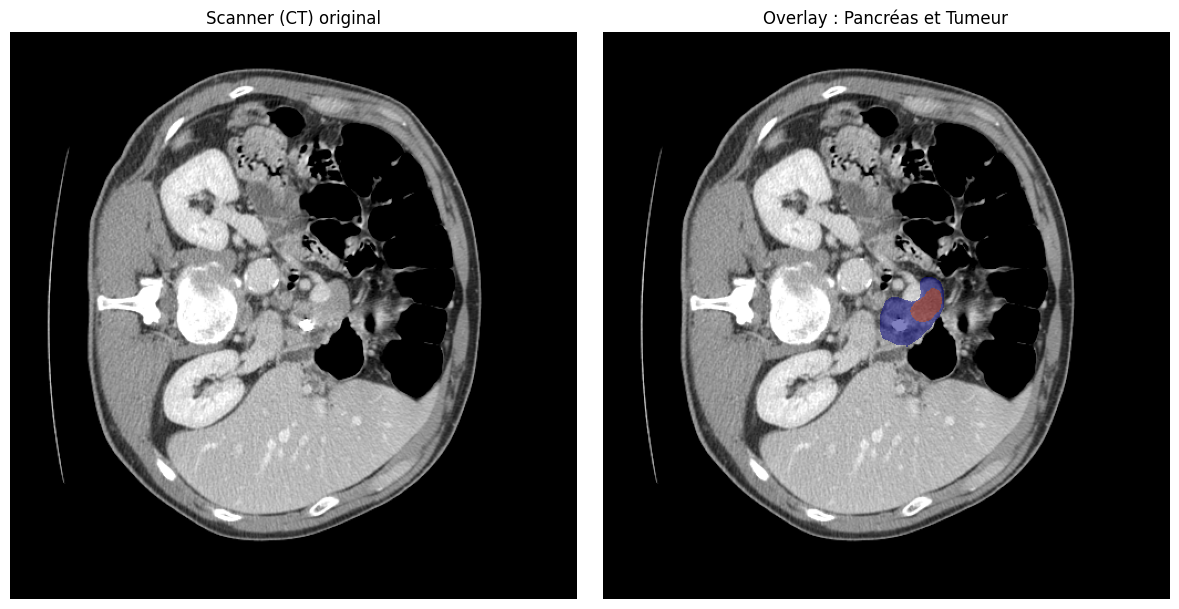

In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img_path = "data/MSD_pancreas/train/images/pancreas_025_s37.png"
mask_path = "data/MSD_pancreas/train/masks/pancreas_025_s37.png"

# 1. Charger l'image et convertir en RGB
image_bgr = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# 2. Charger le masque en niveaux de gris (1 pixel = 1 ID de classe)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

# 3. Création de la figure
plt.figure(figsize=(12, 6))

# Sous-intrigue 1 : Image brute
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Scanner (CT) original")
plt.axis("off")

# Sous-intrigue 2 : Superposition
plt.subplot(1, 2, 2)
plt.imshow(image_rgb)

# On affiche le masque avec une transparence de 40% (alpha=0.4)
# 'jet' permet de colorer le Pancréas (1) et la Tumeur (2) différemment
# On utilise masked_where pour ne pas colorer le fond (0)
masked_data = np.ma.masked_where(mask == 0, mask)
plt.imshow(masked_data, alpha=0.5, cmap="jet", interpolation='none')

plt.title("Overlay : Pancréas et Tumeur")
plt.axis("off")

plt.tight_layout()
plt.show()